In [8]:
np.exp(-0.25)

np.float64(0.7788007830714049)

In [9]:
np.exp(0.25)

np.float64(1.2840254166877414)

Processing LY2090314


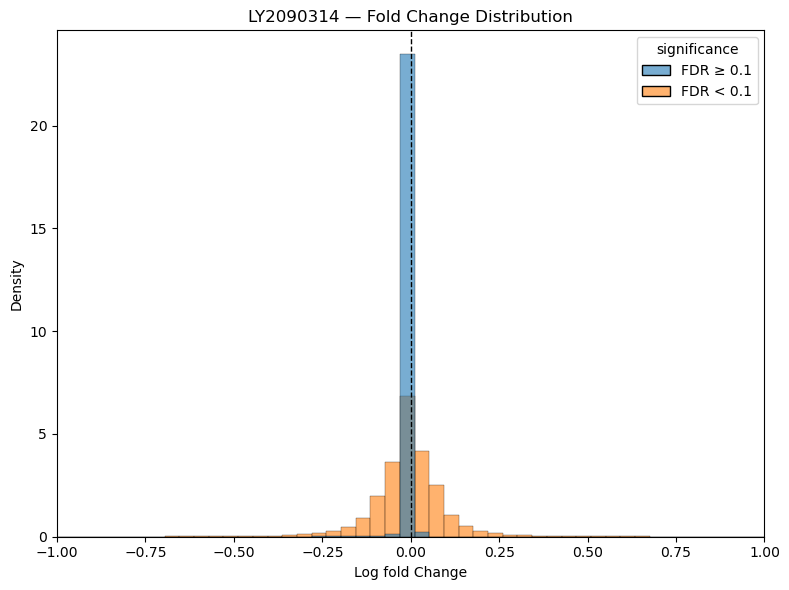

Processing CHIR-98014


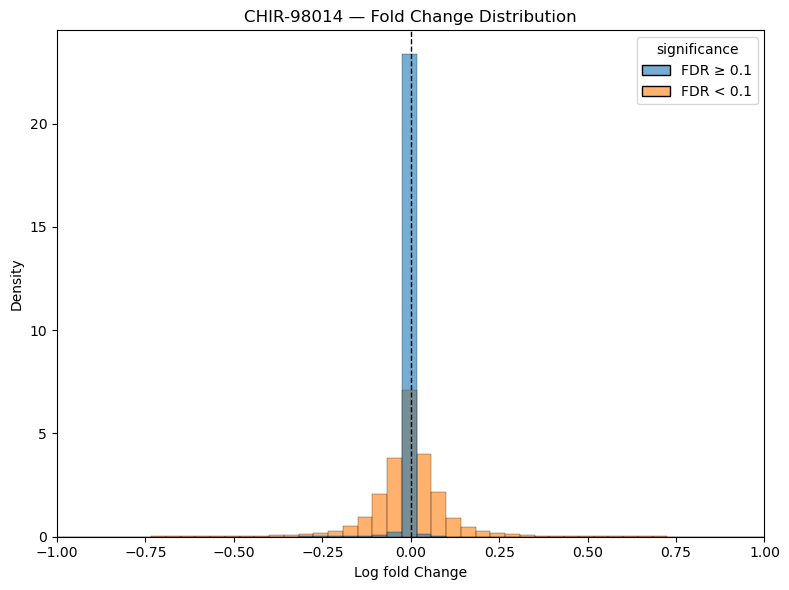

Processing AZD4573


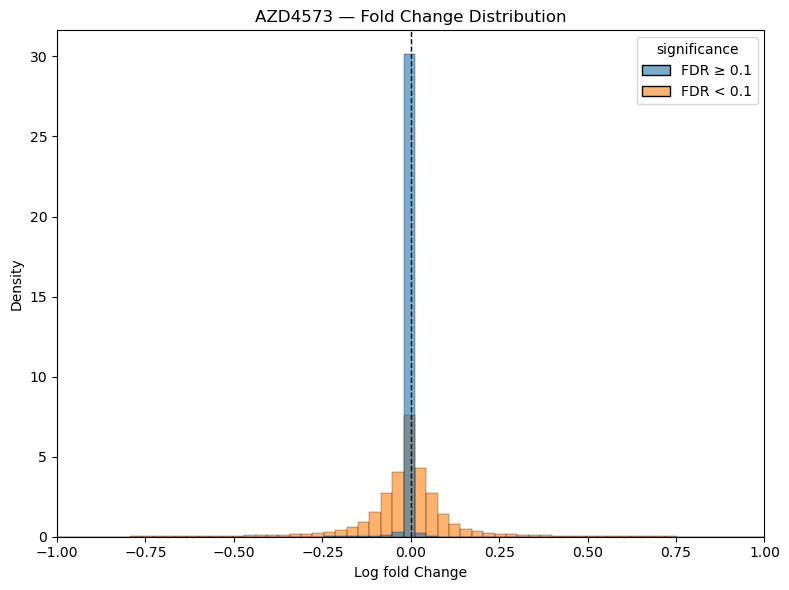

Processing DMSO_round2


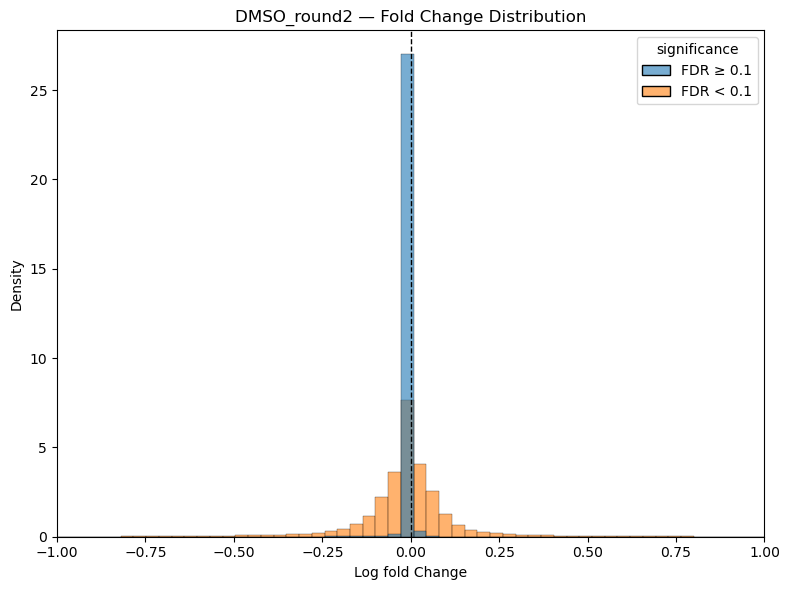

Processing DG-172


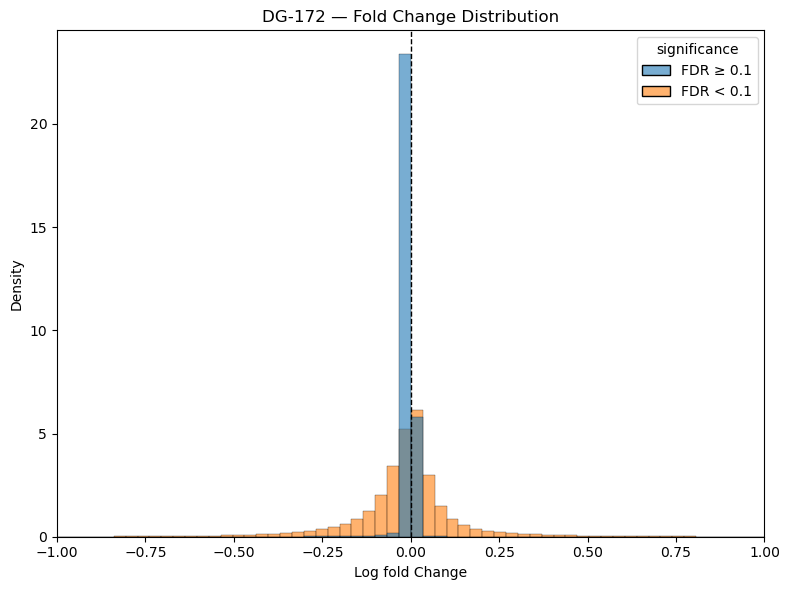

Processing PP121


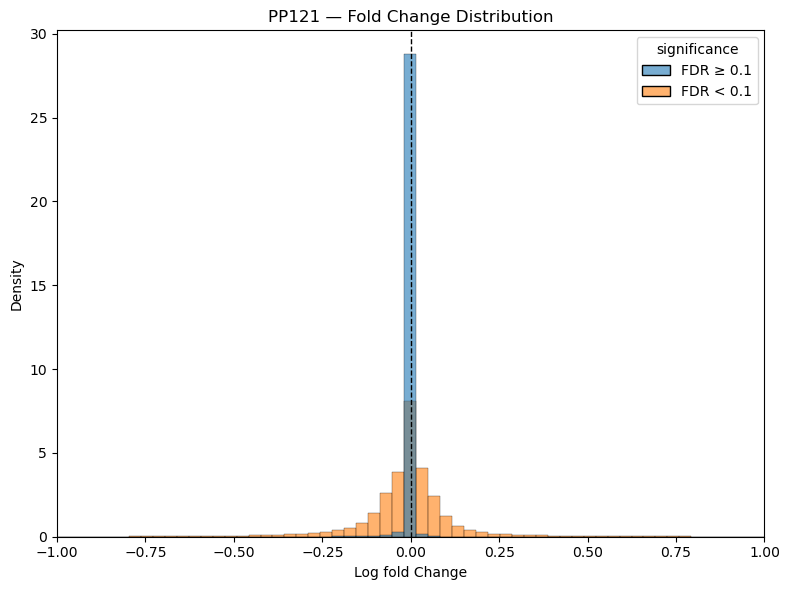

Processing DMSO_round2_batch2


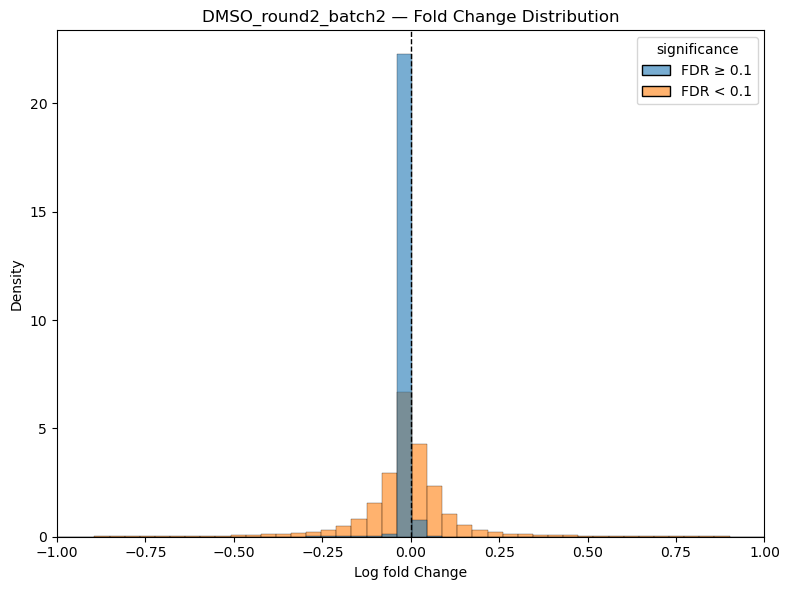

Processing Lexibulin


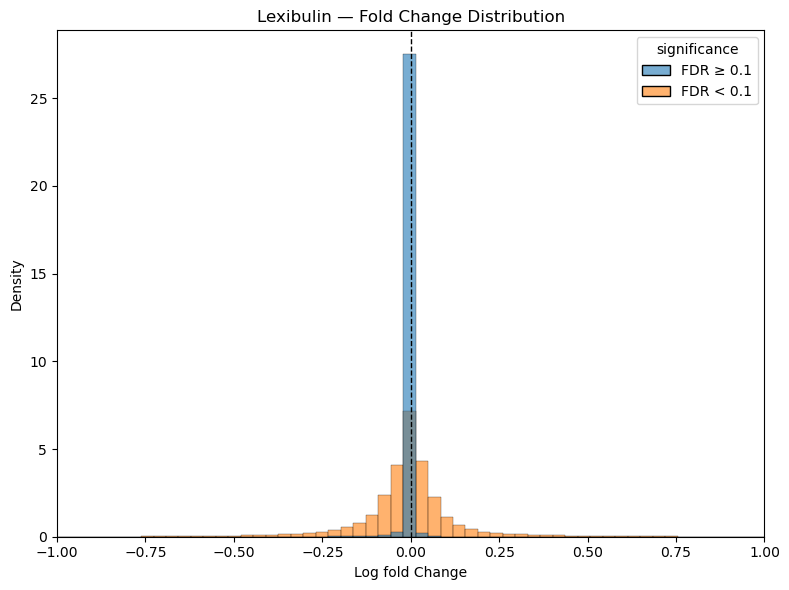

Processing VX-11e


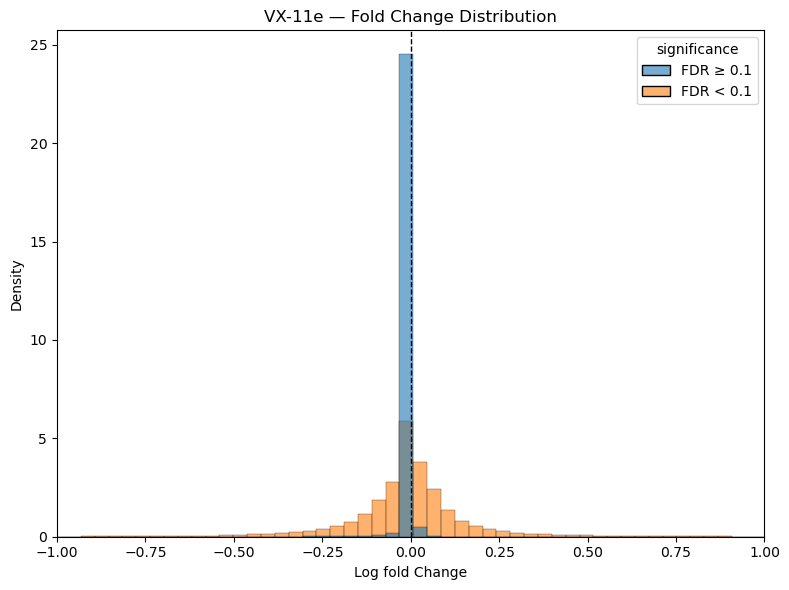

Processing JTE-607


KeyboardInterrupt: 

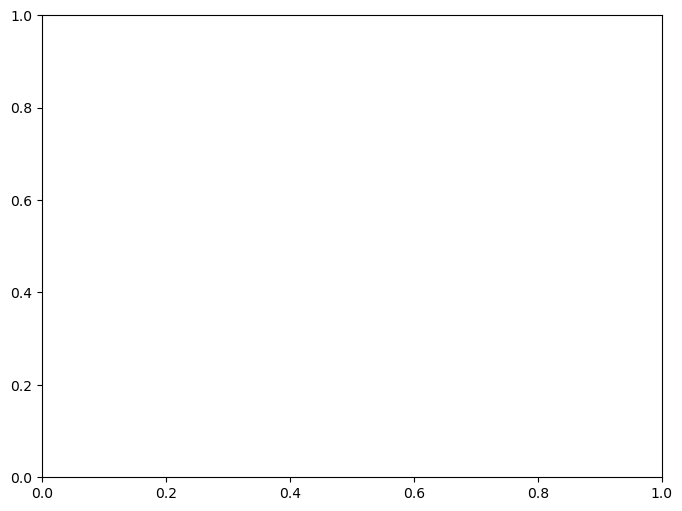

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fc_dir = "./../../PosteriorMeanMatrices/"
fdr_dir = "./../../FDR_matrices/"

fdr_threshold = 0.1

fc_files = [f for f in os.listdir(fc_dir) if f.startswith("PosteriorMean_matrix_") and f.endswith(".csv")]

for fc_file in fc_files:
    drug = fc_file.replace("PosteriorMean_matrix_", "").replace(".csv", "")
    fdr_file = f"{drug}_FDRs.csv"

    fc_path = os.path.join(fc_dir, fc_file)
    fdr_path = os.path.join(fdr_dir, fdr_file)

    if not os.path.exists(fdr_path):
        print(f"Skipping {drug}: FDR file missing")
        continue

    print(f"Processing {drug}")

    # Read matrices
    fc = pd.read_csv(fc_path, index_col=0)
    fdr = pd.read_csv(fdr_path, index_col=0)

    # Find common rows and columns
    common_rows = fc.index.intersection(fdr.index)
    common_cols = fc.columns.intersection(fdr.columns)

    if len(common_rows) == 0 or len(common_cols) == 0:
        print(f"Skipping {drug}: no overlapping rows/columns")
        continue

    # Align both matrices to the same order
    fc = fc.loc[common_rows, common_cols]
    fdr = fdr.loc[common_rows, common_cols]

    # Flatten
    fc_vals = fc.to_numpy().ravel()
    fdr_vals = fdr.to_numpy().ravel()

    # Remove NaNs
    mask = np.isfinite(fc_vals) & np.isfinite(fdr_vals)
    fc_vals = fc_vals[mask]
    fdr_vals = fdr_vals[mask]

    # Build plotting dataframe
    df = pd.DataFrame({
        "fold_change": fc_vals,
        "significance": np.where(fdr_vals < fdr_threshold, "FDR < 0.1", "FDR ≥ 0.1")
    })

    # Plot
    plt.figure(figsize=(8, 6))

    sns.histplot(
        data=df,
        x="fold_change",
        hue="significance",
        bins=200,
        stat="density",
        common_norm=False,
        alpha=0.6
    )

    plt.xlim(-1,1)
    plt.axvline(0, linestyle="--", color="black", linewidth=1)
    plt.title(f"{drug} — Fold Change Distribution")
    plt.xlabel("Log fold Change")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

Processing DG-172


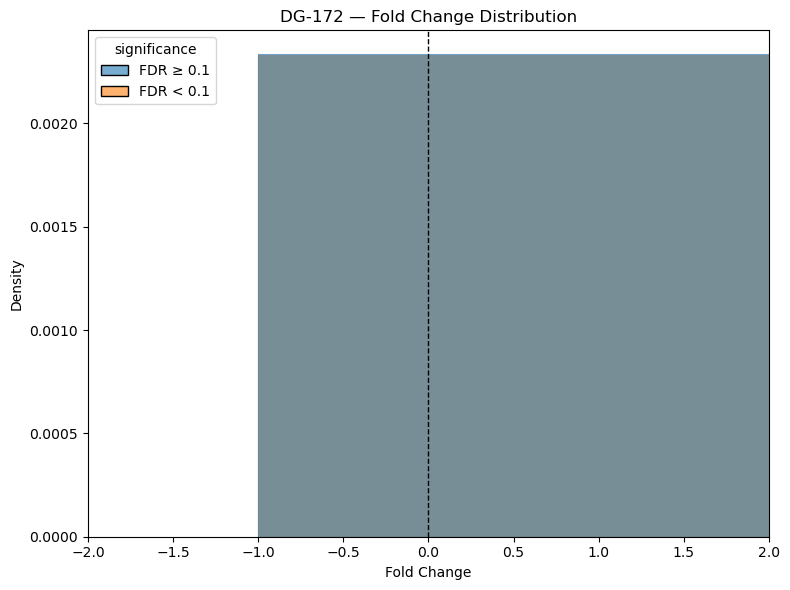

Processing LDN-193189


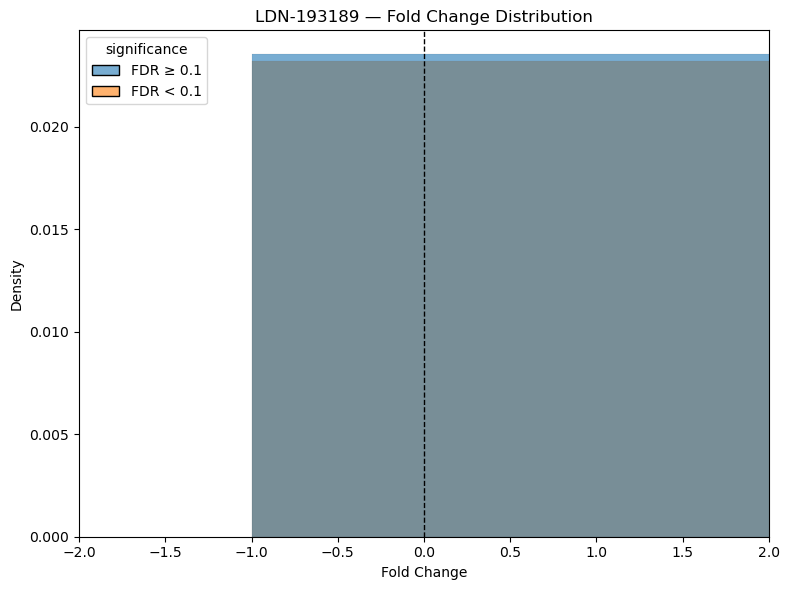

Processing AR-A014418


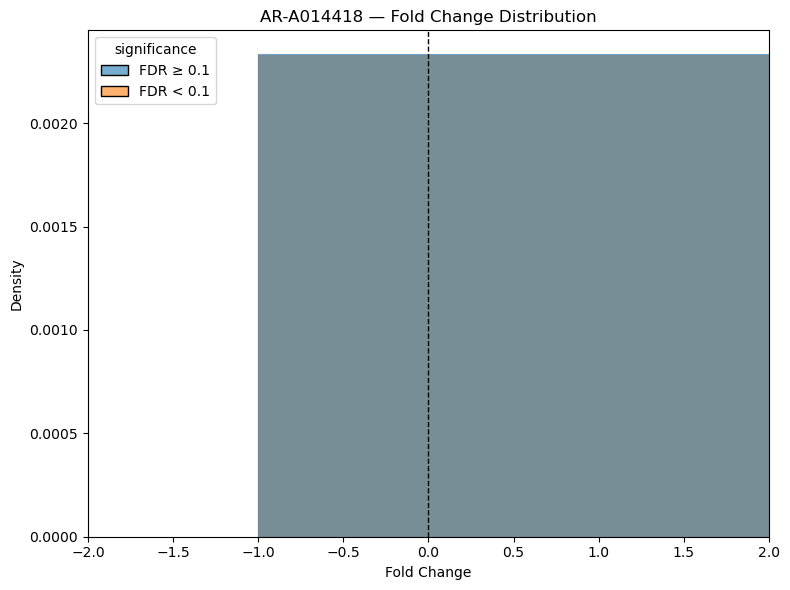

Processing Lexibulin


KeyboardInterrupt: 

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fc_dir = "./../../FC_matrices/"
fdr_dir = "./../../FDR_matrices/"


fdr_threshold = 0.1

# find fold change files
fc_files = [f for f in os.listdir(fc_dir) if f.endswith("_FCs.csv")]

for fc_file in fc_files:

    drug = fc_file.replace("_FCs.csv", "")
    fdr_file = f"{drug}_FDRs.csv"

    fc_path = os.path.join(fc_dir, fc_file)
    fdr_path = os.path.join(fdr_dir, fdr_file)

    if not os.path.exists(fdr_path):
        print(f"Skipping {drug}: FDR file missing")
        continue

    print(f"Processing {drug}")

    # read matrices
    fc = pd.read_csv(fc_path, index_col=0)
    fdr = pd.read_csv(fdr_path, index_col=0)

    # align rows and columns
    common_rows = fc.index.intersection(fdr.index)
    common_cols = fc.columns.intersection(fdr.columns)

    if len(common_rows) == 0 or len(common_cols) == 0:
        print(f"Skipping {drug}: no overlapping rows/columns")
        continue

    fc = fc.loc[common_rows, common_cols]
    fdr = fdr.loc[common_rows, common_cols]

    # flatten matrices
    fc_vals = fc.to_numpy().ravel()
    fdr_vals = fdr.to_numpy().ravel()

    # remove NaNs
    mask = np.isfinite(fc_vals) & np.isfinite(fdr_vals)
    fc_vals = fc_vals[mask]
    fdr_vals = fdr_vals[mask]

    df = pd.DataFrame({
        "fold_change": fc_vals,
        "significance": np.where(fdr_vals < fdr_threshold, "FDR < 0.1", "FDR ≥ 0.1")
    })

    # plot
    plt.figure(figsize=(8,6))

    sns.histplot(
        data=df,
        x="fold_change",
        hue="significance",
        bins=1000,
        stat="density",
        common_norm=False,
        alpha=0.6
    )

    plt.xlim(-2,2)
    plt.axvline(0, linestyle="--", color="black", linewidth=1)

    plt.title(f"{drug} — Fold Change Distribution")
    plt.xlabel("Fold Change")
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()